# 22 &middot; Fast Mass Springs &mdash; a constant-Hessian implicit solver

A mass-spring system stepped with **implicit (backward) Euler** solves, every step,

\[
x_{n+1} = \arg\min_x \; \tfrac{1}{2h^2}\,\lVert x - y\rVert_M^2 \;+\; E_\text{spring}(x),
\qquad y = x_n + h v_n + h^2 g .
\]

The spring energy \(E_\text{spring}=\sum_s \tfrac{k_s}{2}\,(\lVert x_i-x_j\rVert - r_s)^2\)
is **non-convex** (the rest-length term), so a straight Newton solve must rebuild and
**re-factorize** the Hessian every iteration. Liu et al. show a better way: introduce
one auxiliary direction \(d_s\) per spring and write

\[
E_\text{spring}(x) = \min_{\lVert d_s\rVert=r_s}\; \sum_s \tfrac{k_s}{2}\,\lVert (x_i-x_j) - d_s\rVert^2 .
\]

Now the step alternates a **local** projection (set each \(d_s\) to the rest length
along the current spring direction) and a **global** solve. With the \(d_s\) fixed the
objective is quadratic and its system matrix

\[
\big(\tfrac{1}{h^2}M + G^\top W G\big)
\]

is built only from rest data &mdash; **constant for the whole simulation**. Factorize it
**once**; every global step is then a back-substitution. That is the "fast" in fast
mass springs.

**Reference.** T. Liu, A. W. Bargteil, J. F. O'Brien, L. Kavan, *"Fast Simulation of
Mass-Spring Systems"*, ACM TOG (SIGGRAPH Asia) 2013. The same local/global +
prefactored-global structure underlies projective dynamics (Bouaziz et al. 2014).

In [1]:
# --- make the *local* simkit (this repo) importable, ahead of any installed copy ---
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
get_ipython().run_line_magic('matplotlib', 'inline')
import time
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import simkit.energies as energies
from simkit.edges import edges as mesh_edges
from simkit.solvers import block_coord
import utils
import warnings; warnings.filterwarnings("ignore")
np.seterr(all="ignore")           # quiet the line search's harmless overflow probes
os.makedirs("media", exist_ok=True)

## A cloth and its constant global matrix

The cloth is a triangulated grid; its springs are the triangle edges (structural +
shear). We pin the two **top corners** and let it drape under gravity. Below we build
the edge-difference operator \(G\) (so \(Gx\) stacks the spring vectors \(x_j-x_i\)),
the spring weights \(W=\mathrm{diag}(k_s)\otimes I\), the lumped mass \(M\), and the
**constant** system matrix \(H_c = M/h^2 + G^\top W G\), which we factorize once.

In [2]:
X, T = utils.triangulated_grid(nx=25, ny=25, width=2.0, height=2.0)
n, dim = X.shape
E  = mesh_edges(T)                                  # unique edges -> springs
ne = E.shape[0]
print(f"{n} nodes, {ne} springs")

l0 = np.linalg.norm(X[E[:, 1]] - X[E[:, 0]], axis=1)[:, None]    # rest lengths
ym = np.full((ne, 1), 80.0)                                      # per-spring stiffness
k  = (ym / l0 ** 2).flatten()                                    # Hooke stiffness  k = ym/l0^2

# edge-difference operator  G : flattened x -> stacked spring vectors  d_e = x_j - x_i
rows = np.repeat(np.arange(ne), 2); cols = E.reshape(-1); vals = np.tile([-1.0, 1.0], ne)
Sinc = sp.sparse.csc_matrix((vals, (rows, cols)), shape=(ne, n))
G = sp.sparse.kron(Sinc, sp.sparse.eye(dim)).tocsc()
W = sp.sparse.kron(sp.sparse.diags(k), sp.sparse.eye(dim)).tocsc()

# lumped mass, gravity, timestep
M = sp.sparse.eye(n * dim).tocsc()
h = 1.0 / 30.0
gvec = np.tile([0.0, -9.8], n).reshape(-1, 1)

# pin the two top corners
ytop = X[:, 1].max()
corners = np.where((X[:, 1] >= ytop - 1e-9) &
                   ((X[:, 0] <= X[:, 0].min() + 1e-9) | (X[:, 0] >= X[:, 0].max() - 1e-9)))[0]
pin_dof  = (corners[:, None] * dim + np.arange(dim)).ravel()
free_dof = np.setdiff1d(np.arange(n * dim), pin_dof)

# THE CONSTANT global matrix  Hc = M/h^2 + G^T W G   (independent of x) -> factor once
Hc    = (M / h ** 2 + G.T @ W @ G).tocsc()
H_ff  = Hc[free_dof][:, free_dof].tocsc()
H_fp  = Hc[free_dof][:, pin_dof].tocsc()
solve = sp.sparse.linalg.factorized(H_ff)           # the ONLY factorization

625 nodes, 1776 springs


## The implicit step as block coordinate descent

`local_step` projects every spring onto its rest-length sphere
(\(d = r\,(x_j-x_i)/\lVert x_j-x_i\rVert\)); `global_step` is the prefactored solve
\(H_c\,x = M y / h^2 + G^\top W d\). We drive the two with simkit's `block_coord`.

In [3]:
xp = X.flatten().reshape(-1, 1)[pin_dof]            # corners stay fixed at rest

def make_full(xf):
    x = np.empty((n * dim, 1)); x[free_dof] = xf; x[pin_dof] = xp; return x

def implicit_step(x, v, n_inner=8):
    # one backward-Euler step via local/global (fast mass springs)
    y = x + h * v + h ** 2 * gvec
    rhs_inertia = (M / h ** 2) @ y

    def local_step(xf):                              # local: project each spring to rest length
        d = (G @ make_full(xf)).reshape(-1, dim)
        d = l0 * d / np.linalg.norm(d, axis=1, keepdims=True)
        return d.reshape(-1, 1)

    def global_step(xf, d):                          # global: prefactored constant solve
        rhs = (rhs_inertia + G.T @ (W @ d))[free_dof] - H_fp @ xp
        return solve(rhs).reshape(-1, 1)

    xf = block_coord(x[free_dof].copy(), global_step, local_step, max_iter=n_inner, tolerance=0.0)
    x_new = make_full(xf)
    v_new = (x_new - x) / h
    return x_new, v_new

## "Constant Hessian": local/global vs. Newton

The local/global matrix \(H_c\) is built only from rest data, so it never changes
&mdash; one factorization serves the whole run. A Newton implicit solve instead uses
\(M/h^2 + G^\top H_\text{spring}(x)\,G\), whose spring block depends on the current
positions and must be reassembled and re-factorized at every iteration. Let's verify.

In [4]:
def newton_hessian(x):
    d  = (G @ x).reshape(-1, dim)
    He = energies.mass_springs_hessian_element_d(d, ym, l0)      # per-spring, depends on x
    Hd = sp.sparse.block_diag(He).tocsc()
    return (M / h ** 2 + G.T @ Hd @ G).tocsc()

rng   = np.random.default_rng(0)
x_a   = X.flatten().reshape(-1, 1)
x_b   = (X + 0.3 * rng.standard_normal(X.shape)).flatten().reshape(-1, 1)
dHn   = sp.sparse.linalg.norm(newton_hessian(x_a) - newton_hessian(x_b))
print(f"Newton implicit Hessian, ||H(x_a) - H(x_b)|| = {dHn:.3e}   (nonzero -> rebuild + refactorize every iter)")
print(f"Local/global matrix Hc is state-independent   = {sp.sparse.linalg.norm(Hc - Hc):.3e}   (always 0 -> factor once)")

Newton implicit Hessian, ||H(x_a) - H(x_b)|| = 9.610e+05   (nonzero -> rebuild + refactorize every iter)
Local/global matrix Hc is state-independent   = 0.000e+00   (always 0 -> factor once)


## Drop the cloth

Released flat from rest, held at the two top corners, settling under gravity. The
solver is unconditionally stable (implicit), so a large \(h=1/30\) and only 8 inner
local/global iterations per step are plenty.

In [5]:
x = X.flatten().reshape(-1, 1).copy()
v = np.zeros_like(x)
states = [x.reshape(n, dim).copy()]
n_steps = 240
t0 = time.perf_counter()
for _ in range(n_steps):
    x, v = implicit_step(x, v, n_inner=8)
    states.append(x.reshape(n, dim).copy())
print(f"{n_steps} implicit steps in {time.perf_counter()-t0:.2f} s  (one factorization reused throughout)")

240 implicit steps in 0.18 s  (one factorization reused throughout)



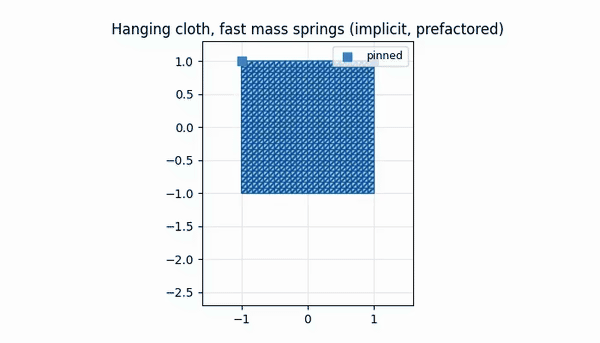

In [6]:
def thin(states, target=120):
    k = max(1, len(states) // target); idx = list(range(0, len(states), k))
    if idx[-1] != len(states) - 1: idx.append(len(states) - 1)
    return [states[i] for i in idx]

lims = ((-1.6, 1.6), (-2.7, 1.3))
fig, anim = utils.animate_mesh(thin(states), T, lims=lims, fps=30,
    title="Hanging cloth, fast mass springs (implicit, prefactored)", pin_pts=X[corners])
utils.save_anim(anim, "media/22_cloth.mp4", fps=30); plt.close(fig)
utils.show_anim(anim)

## What the constant matrix buys per step

Per implicit step, the local/global solver does a handful of back-substitutions
through one cached factorization; a Newton step instead reassembles and
re-factorizes its state-dependent Hessian at every inner iteration. Same problem,
very different per-step cost.

In [7]:
xt = states[5].flatten().reshape(-1, 1)
vt = (states[5] - states[4]).flatten().reshape(-1, 1) / h
y  = xt + h * vt + h ** 2 * gvec
rhs_inertia = (M / h ** 2) @ y

# fast: 8 prefactored back-substitutions (reuse the one factorization)
t0 = time.perf_counter()
for _ in range(8):
    d = (G @ xt).reshape(-1, dim); d = l0 * d / np.linalg.norm(d, axis=1, keepdims=True)
    _ = solve((rhs_inertia + G.T @ (W @ d.reshape(-1, 1)))[free_dof] - H_fp @ xp)
t_fast = time.perf_counter() - t0

# newton-style: assemble + factorize the state-dependent Hessian each iteration
t0 = time.perf_counter()
for _ in range(8):
    Hn = newton_hessian(xt)[free_dof][:, free_dof].tocsc()
    _ = sp.sparse.linalg.spsolve(Hn, np.ones((len(free_dof), 1)))
t_newton = time.perf_counter() - t0

print(f"per step (8 inner iters):  fast local/global {1e3*t_fast:6.1f} ms   vs   refactorizing {1e3*t_newton:6.1f} ms")

per step (8 inner iters):  fast local/global    2.2 ms   vs   refactorizing   60.3 ms


## Takeaways

* **The reformulation makes the system matrix constant.** Splitting each spring's
  energy with an auxiliary direction turns the global step into a quadratic solve
  with a fixed matrix \(M/h^2 + G^\top W G\). Factor it once at setup; every step and
  every inner iteration thereafter is a cheap back-substitution.
* **This is the same machinery as tutorial 21.** Local step = closed-form per-element
  projection (here, a spring onto its rest length; for ARAP, a triangle onto its
  closest rotation). Global step = one prefactored linear solve. Block coordinate
  descent (`simkit.solvers.block_coord`) drives both.
* **Implicit + prefactored = fast and stable.** A big timestep stays stable, and the
  per-step cost is dominated by sparse back-substitutions rather than repeated
  factorizations &mdash; exactly the win reported by Liu et al. (2013).